# Breast Cancer Wisconsin (Diagnostic) — Model Training

This notebook trains and evaluates several machine-learning classifiers for the **Cancer Disease** module.

## Input dataset

`data/processed/cancer_disease_clean.csv`

## Target

- `0` = Benign
- `1` = Malignant

## Features

The model uses all **30 diagnostic numerical measurements** retained by the exploration notebook.

The workflow:

1. Load and validate the processed dataset.
2. Split the data into Train / Validation / Test sets.
3. Build a leakage-safe preprocessing pipeline.
4. Compare multiple classification algorithms.
5. Select the best model using validation ROC-AUC.
6. Tune the decision threshold using the validation set only.
7. Evaluate once on the untouched test set.
8. Save the final model artifact for Streamlit.


In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

current_folder = Path.cwd()

project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "cancer_disease_clean.csv"
)

models_folder = (
    project_root
    / "models"
)

figures_folder = (
    project_root
    / "reports"
    / "figures"
)

model_output_path = (
    models_folder
    / "cancer_disease_model.joblib"
)

models_folder.mkdir(
    parents=True,
    exist_ok=True,
)

figures_folder.mkdir(
    parents=True,
    exist_ok=True,
)

print("Processed dataset:", processed_data_path)
print("File exists:", processed_data_path.exists())

if not processed_data_path.exists():
    raise FileNotFoundError(
        "Run 11_cancer_data_exploration.ipynb first."
    )

Processed dataset: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\cancer_disease_clean.csv
File exists: True


In [2]:
# Load the cleaned dataset
data = pd.read_csv(
    processed_data_path
)

print("Dataset shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

display(data.head())

print("\nMissing values:")
print(data.isnull().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
print(
    data["cancer_diagnosis"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages:")
print(
    data["cancer_diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Dataset shape: (569, 31)

Columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'cancer_diagnosis']


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst,cancer_diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1



Missing values:
radius_mean               0
texture_mean              0
perimeter_mean            0
area_mean                 0
smoothness_mean           0
compactness_mean          0
concavity_mean            0
concave_points_mean       0
symmetry_mean             0
fractal_dimension_mean    0
dtype: int64

Target distribution:
cancer_diagnosis
0    357
1    212
Name: count, dtype: int64

Target percentages:
cancer_diagnosis
0    62.74
1    37.26
Name: proportion, dtype: float64


In [3]:
# Define predictors and target
target_column = "cancer_diagnosis"

feature_columns = [
    column
    for column in data.columns
    if column != target_column
]

X = (
    data[feature_columns]
    .copy()
)

y = (
    data[target_column]
    .astype(int)
    .copy()
)

print("Number of features:", len(feature_columns))
print("Target:", target_column)
print("Positive class (malignant) rate:", f"{y.mean():.2%}")

if len(feature_columns) != 30:
    raise ValueError(
        f"Expected 30 cancer features, found {len(feature_columns)}."
    )

if not set(y.unique()).issubset({0, 1}):
    raise ValueError(
        f"Unexpected target values: {sorted(y.unique())}"
    )

Number of features: 30
Target: cancer_diagnosis
Positive class (malignant) rate: 37.26%


## Train / Validation / Test Split

A stratified split is used:

- **60% Training**
- **20% Validation**
- **20% Test**

The test set remains untouched until the final evaluation.


In [4]:
# 60% training, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Split the temporary set equally:
# 20% validation + 20% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nMalignant-class ratios:")
print("Train:", round(y_train.mean(), 4))
print("Validation:", round(y_validation.mean(), 4))
print("Test:", round(y_test.mean(), 4))

Training set: (341, 30) (341,)
Validation set: (114, 30) (114,)
Test set: (114, 30) (114,)

Malignant-class ratios:
Train: 0.3724
Validation: 0.3772
Test: 0.3684


In [5]:
# Reusable preprocessing pipeline
#
# Median imputation is included for robustness even though the
# current cleaned dataset should contain no missing values.
#
# StandardScaler is useful for Logistic Regression and SVM.
preprocessor = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [6]:
# Candidate models
candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=600,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=600,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Support Vector Machine": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
validation_rows = []

for model_name, classifier in candidate_models.items():

    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor,
            ),
            (
                "classifier",
                classifier,
            ),
        ]
    )

    pipeline.fit(
        X_train,
        y_train,
    )

    validation_probability = (
        pipeline.predict_proba(
            X_validation
        )[:, 1]
    )

    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_validation,
            validation_prediction,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            validation_prediction,
        ),
        "Precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_validation,
            validation_probability,
        ),
    }

    validation_rows.append(row)
    trained_models[model_name] = pipeline

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(
        [
            "ROC-AUC",
            "Balanced Accuracy",
            "F1",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    validation_results.style.format(
        {
            "Accuracy": "{:.4f}",
            "Balanced Accuracy": "{:.4f}",
            "Precision": "{:.4f}",
            "Recall": "{:.4f}",
            "F1": "{:.4f}",
            "ROC-AUC": "{:.4f}",
        }
    )
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9825,0.9767,1.0000,0.9535,0.9762,1.0000
1,Support Vector Machine,0.9737,0.9651,1.0000,0.9302,0.9639,0.9997
2,Extra Trees,0.9737,0.9697,0.9762,0.9535,0.9647,0.9984
3,Random Forest,0.9649,0.9581,0.9756,0.9302,0.9524,0.9977


In [7]:
# Select the strongest validation model
best_model_name = (
    validation_results
    .iloc[0]["Model"]
)

best_pipeline = (
    trained_models[
        best_model_name
    ]
)

best_validation_probability = (
    best_pipeline
    .predict_proba(
        X_validation
    )[:, 1]
)

print("Selected model:", best_model_name)

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            best_validation_probability,
        ),
        4,
    ),
)

Selected model: Logistic Regression
Validation ROC-AUC: 1.0


## Decision Threshold

Instead of automatically forcing the default `0.50` threshold, the notebook selects a threshold using the **validation set only**.

The selection criterion is **Youden's J statistic**, which balances:

- Sensitivity / Recall for malignant cases
- Specificity for benign cases

The untouched test set is not used to choose the threshold.


In [8]:
# Tune threshold on validation data only
threshold_candidates = np.linspace(
    0.05,
    0.95,
    181,
)

threshold_rows = []

for threshold in threshold_candidates:

    prediction = (
        best_validation_probability
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        prediction,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    youden_j = (
        sensitivity
        + specificity
        - 1
    )

    threshold_rows.append(
        {
            "Threshold": threshold,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Youden J": youden_j,
            "Balanced Accuracy": (
                sensitivity
                + specificity
            ) / 2,
            "F1": f1_score(
                y_validation,
                prediction,
                zero_division=0,
            ),
        }
    )

threshold_results = (
    pd.DataFrame(
        threshold_rows
    )
)

best_threshold_row = (
    threshold_results
    .sort_values(
        [
            "Youden J",
            "Sensitivity",
            "Balanced Accuracy",
            "F1",
        ],
        ascending=False,
    )
    .iloc[0]
)

decision_threshold = float(
    best_threshold_row[
        "Threshold"
    ]
)

print(
    "Selected decision threshold:",
    round(
        decision_threshold,
        4,
    ),
)

display(
    best_threshold_row
    .to_frame("Value")
    .style.format("{:.4f}")
)

Selected decision threshold: 0.33


,Value
Threshold,0.3300
Sensitivity,1.0000
Specificity,1.0000
Youden J,1.0000
Balanced Accuracy,1.0000
F1,1.0000


In [9]:
# Final evaluation on the untouched test set
test_probability = (
    best_pipeline
    .predict_proba(
        X_test
    )[:, 1]
)

test_prediction = (
    test_probability
    >= decision_threshold
).astype(int)

test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_prediction,
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        test_prediction,
    ),
    "Precision": precision_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "F1": f1_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probability,
    ),
}

test_metrics_table = pd.DataFrame(
    test_metrics.items(),
    columns=[
        "Metric",
        "Score",
    ],
)

display(
    test_metrics_table.style.format(
        {
            "Score": "{:.4f}"
        }
    )
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "Benign",
            "Malignant",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        test_prediction,
    )
)

,Metric,Score
0,Accuracy,0.9737
1,Balanced Accuracy,0.9692
2,Precision,0.9756
3,Recall,0.9524
4,F1,0.9639
5,ROC-AUC,0.9927



Classification report:
              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Confusion matrix:
[[71  1]
 [ 2 40]]


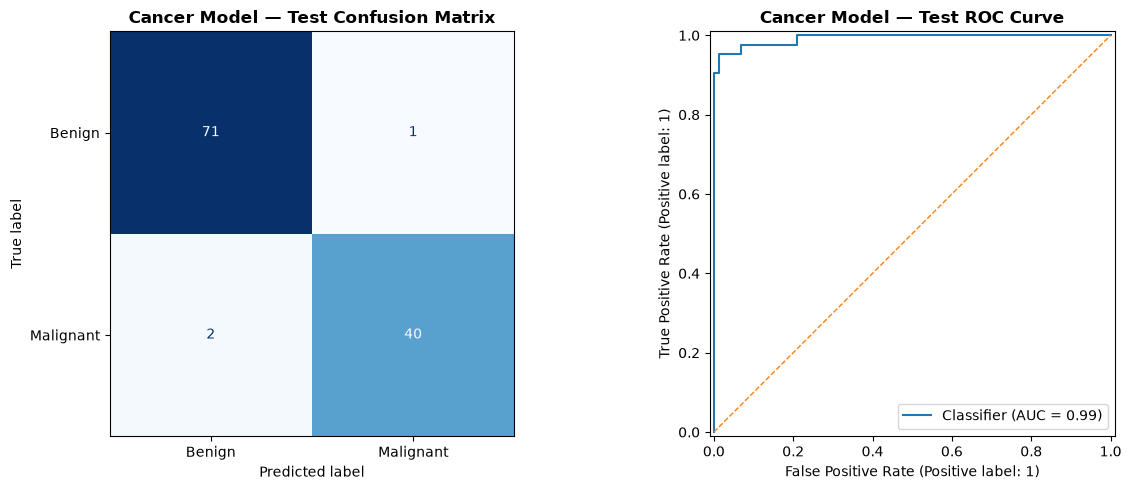

Evaluation figure saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\cancer_model_evaluation.png


In [10]:
# Final test-set visualizations
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=[
        "Benign",
        "Malignant",
    ],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)

axes[0].set_title(
    "Cancer Model — Test Confusion Matrix",
    fontweight="bold",
)

RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    ax=axes[1],
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Cancer Model — Test ROC Curve",
    fontweight="bold",
)

plt.tight_layout()

evaluation_figure_path = (
    figures_folder
    / "cancer_model_evaluation.png"
)

plt.savefig(
    evaluation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Evaluation figure saved:",
    evaluation_figure_path,
)

,Feature,Importance,Signed Coefficient
0,radius_se,1.22566,1.22566
1,texture_worst,1.20514,1.20514
2,symmetry_worst,1.09788,1.09788
3,concave_points_mean,0.99449,0.99449
4,perimeter_se,0.94590,0.94590
5,area_se,0.93335,0.93335
6,concave_points_worst,0.88311,0.88311
7,concavity_mean,0.81371,0.81371
8,compactness_se,0.80606,-0.80606
9,area_worst,0.75982,0.75982


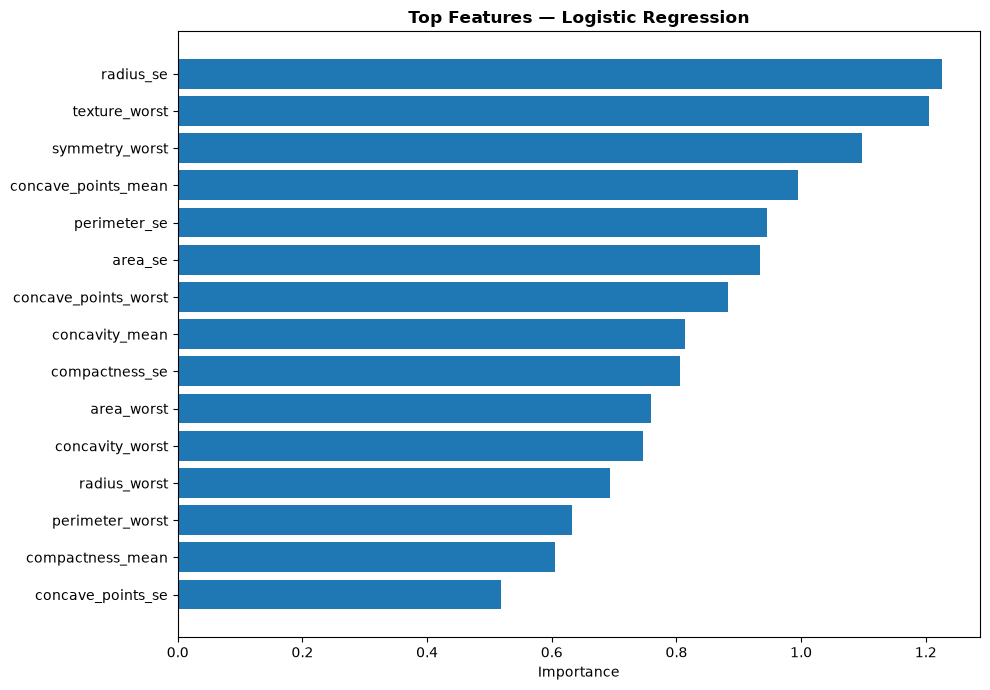

Feature importance figure saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\cancer_model_feature_importance.png


In [11]:
# Extract feature importance / coefficient information when available
classifier = (
    best_pipeline
    .named_steps[
        "classifier"
    ]
)

importance_table = None

if hasattr(
    classifier,
    "feature_importances_",
):
    importance_table = pd.DataFrame(
        {
            "Feature": feature_columns,
            "Importance": classifier.feature_importances_,
        }
    )

elif hasattr(
    classifier,
    "coef_",
):
    coefficients = (
        classifier
        .coef_[0]
    )

    importance_table = pd.DataFrame(
        {
            "Feature": feature_columns,
            "Importance": np.abs(coefficients),
            "Signed Coefficient": coefficients,
        }
    )

if importance_table is not None:

    importance_table = (
        importance_table
        .sort_values(
            "Importance",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    display(
        importance_table
        .head(15)
        .style.format(
            {
                "Importance": "{:.5f}",
                "Signed Coefficient": "{:.5f}",
            }
        )
    )

    top_importance = (
        importance_table
        .head(15)
        .sort_values(
            "Importance",
            ascending=True,
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        top_importance["Feature"],
        top_importance["Importance"],
    )

    plt.title(
        f"Top Features — {best_model_name}",
        fontweight="bold",
    )

    plt.xlabel(
        "Importance"
    )

    plt.tight_layout()

    feature_importance_path = (
        figures_folder
        / "cancer_model_feature_importance.png"
    )

    plt.savefig(
        feature_importance_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Feature importance figure saved:",
        feature_importance_path,
    )

else:
    print(
        f"{best_model_name} does not expose a direct "
        "feature-importance or coefficient attribute."
    )

## Interpretation note

This dataset is well known and often produces strong classification performance. However:

- High test accuracy does not make the application a clinical diagnostic system.
- The 30 measurements come from analysis of a breast mass, not ordinary home measurements.
- The Streamlit page should therefore label these inputs as diagnostic measurement features and avoid implying that a user can obtain them without appropriate clinical testing.


In [12]:
# Save the selected model and metadata
model_artifact = {
    "model": best_pipeline,
    "threshold": decision_threshold,
    "features": feature_columns,
    "target": target_column,
    "target_mapping": {
        0: "Benign",
        1: "Malignant",
    },
    "selected_model": best_model_name,
    "validation_results": (
        validation_results
        .round(6)
        .to_dict(
            orient="records"
        )
    ),
    "test_metrics": {
        key: float(value)
        for key, value
        in test_metrics.items()
    },
    "random_state": RANDOM_STATE,
    "notes": (
        "Educational Breast Cancer Wisconsin Diagnostic model. "
        "ID and empty source column excluded. "
        "All 30 diagnostic numerical measurements retained."
    ),
}

joblib.dump(
    model_artifact,
    model_output_path,
)

print(
    "Model artifact saved successfully:",
    model_output_path,
)

print(
    "File exists:",
    model_output_path.exists(),
)

print(
    "Selected model:",
    model_artifact[
        "selected_model"
    ],
)

print(
    "Decision threshold:",
    round(
        model_artifact[
            "threshold"
        ],
        4,
    ),
)

print(
    "Number of features:",
    len(
        model_artifact[
            "features"
        ]
    ),
)

Model artifact saved successfully: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\cancer_disease_model.joblib
File exists: True
Selected model: Logistic Regression
Decision threshold: 0.33
Number of features: 30


In [13]:
# Reload the saved artifact and run a sanity check
reloaded_artifact = joblib.load(
    model_output_path
)

reloaded_model = (
    reloaded_artifact[
        "model"
    ]
)

reloaded_threshold = float(
    reloaded_artifact[
        "threshold"
    ]
)

# Use one real test-set record only as a technical pipeline check
sample_input = (
    X_test
    .iloc[[0]]
    .copy()
)

sample_true_label = int(
    y_test
    .iloc[0]
)

sample_score = float(
    reloaded_model
    .predict_proba(
        sample_input
    )[0, 1]
)

sample_prediction = int(
    sample_score
    >= reloaded_threshold
)

print("Sanity-check sample:")
display(sample_input)

print(
    "True class:",
    reloaded_artifact[
        "target_mapping"
    ][sample_true_label],
)

print(
    "Model score:",
    round(
        sample_score,
        4,
    ),
)

print(
    "Predicted class:",
    reloaded_artifact[
        "target_mapping"
    ][sample_prediction],
)

print("\nSaved artifact keys:")
print(
    list(
        reloaded_artifact.keys()
    )
)

Sanity-check sample:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
84,12.0,15.65,76.95,443.3,0.09723,0.07165,0.04151,0.01863,0.2079,0.05968,0.2271,1.255,1.441,16.16,0.005969,0.01812,0.02007,0.007027,0.01972,0.002607,13.67,24.9,87.78,567.9,0.1377,0.2003,0.2267,0.07632,0.3379,0.07924


True class: Benign
Model score: 0.008
Predicted class: Benign

Saved artifact keys:
['model', 'threshold', 'features', 'target', 'target_mapping', 'selected_model', 'validation_results', 'test_metrics', 'random_state', 'notes']


## Output

After successful execution, this notebook creates:

```text
models/cancer_disease_model.joblib
reports/figures/cancer_model_evaluation.png
reports/figures/cancer_model_feature_importance.png
```
